# A Gemma feature, two views

What does feature **layer 0 / index 24** respond to? We inspect it from two directions:

- **WeightLens** projects the feature into token space.
- **CircuitLens** traces which attention heads and source tokens drive it in context.

The model and transcoders come from the public [Circuit Tracer](https://github.com/safety-research/circuit-tracer) release for Gemma-2-2B.

## Load the feature

This notebook needs Gemma access on Hugging Face and about 16 GB of accelerator memory. The bundled sample contains 12 published inputs for the chosen feature.

In [1]:
from __future__ import annotations

import json
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
import torch
from circuit_tracer import ReplacementModel
from huggingface_hub import snapshot_download
from IPython.display import Markdown, display
from tensordict import NonTensorData, TensorDict
from tensordict.nn import TensorDictModule
from transformers import AutoTokenizer

from tdhook.attribution import CircuitLensArtifact, attention_contributions, cluster_circuit_artifacts
from tdhook.weights import analyze_input_invariant_feature, select_projection_outliers
from tdhook.workflow import Workflow

SEED = 127
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)

if not torch.cuda.is_available():
    raise RuntimeError("This Gemma-2-2B notebook requires CUDA.")

device = torch.device("cuda")
dtype = torch.bfloat16
reference_relative_path = Path("docs/source/notebooks/assets/gemma-2-2b-feature-24-reference.json")
reference_path = next(
    root / reference_relative_path
    for root in (Path.cwd(), *Path.cwd().parents)
    if (root / reference_relative_path).is_file()
)
reference = json.loads(reference_path.read_text())
feature_layer = reference["feature"]["layer"]
feature_index = reference["feature"]["index"]

In [2]:
model_snapshot = snapshot_download(
    reference["provenance"]["model"],
    revision=reference["provenance"]["model_revision"],
    allow_patterns=[
        "config.json",
        "special_tokens_map.json",
        "tokenizer.json",
        "tokenizer.model",
        "tokenizer_config.json",
    ],
)
tokenizer = AutoTokenizer.from_pretrained(model_snapshot)

model = ReplacementModel.from_pretrained(
    reference["provenance"]["model"],
    f"{reference['provenance']['transcoder_set']}@{reference['provenance']['transcoder_revision']}",
    revision=reference["provenance"]["model_revision"],
    device=device,
    dtype=dtype,
    tokenizer=tokenizer,
)
model.eval()

selected_transcoder = model.transcoders[feature_layer]


def encoder_for_tdhook(transcoder):
    """Normalize circuit-tracer releases to TDHook's [model, feature] convention."""
    weights = transcoder.W_enc
    if weights.shape[0] == model.cfg.d_model:
        return weights
    if weights.shape[1] == model.cfg.d_model:
        return weights.T
    raise ValueError(f"Unrecognized encoder shape: {tuple(weights.shape)}")


# The selected feature is in layer 0, so WeightLens needs no earlier dictionaries.
# Keeping one layer also avoids materializing every lazily loaded decoder.
feature_encoders = (encoder_for_tdhook(selected_transcoder),)
feature_decoders = (selected_transcoder.W_dec,)
token_labels = tuple(model.tokenizer.decode([index]) for index in range(model.cfg.d_vocab))

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Fetching 26 files:   0%|          | 0/26 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded pretrained model google/gemma-2-2b into HookedTransformer


## WeightLens: token associations

A `Workflow` projects the feature encoder into the embedding dictionary and its decoder into the output dictionary, then publishes the selected token views as named TensorDict artifacts. Large positive or negative projections reveal the feature's input and output associations.

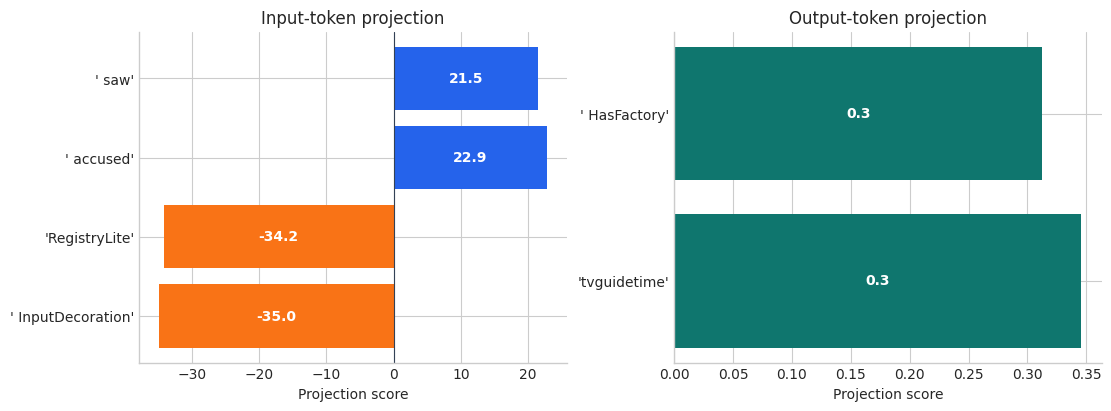

In [3]:
def project_feature():
    artifact = analyze_input_invariant_feature(
        feature_layer=feature_layer,
        feature_index=feature_index,
        embedding=model.W_E,
        unembedding=model.W_U,
        feature_encoders=feature_encoders,
        feature_decoders=feature_decoders,
        token_outlier_threshold=5.5,
        feature_outlier_threshold=4.0,
        token_pool_size=1000,
        feature_pool_size=100,
        input_token_labels=token_labels,
        output_token_labels=token_labels,
    )
    return NonTensorData(artifact)


def select_token_views(artifact):
    inputs = (*artifact.embedding_negative, *artifact.embedding_positive)
    return NonTensorData(inputs), NonTensorData(tuple(artifact.output_positive))


weight_lens_workflow = Workflow(
    TensorDictModule(project_feature, in_keys=[], out_keys=[("artifacts", "weight_lens")]),
    TensorDictModule(
        select_token_views,
        in_keys=[("artifacts", "weight_lens")],
        out_keys=[("views", "input_tokens"), ("views", "output_tokens")],
    ),
)
weight_result = weight_lens_workflow(model, TensorDict({}, batch_size=[]))
weight_artifact = weight_result[("artifacts", "weight_lens")]
input_items = list(weight_result[("views", "input_tokens")])
output_items = list(weight_result[("views", "output_tokens")])

with plt.style.context("seaborn-v0_8-whitegrid"):
    figure, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
    input_bars = axes[0].barh(
        [repr(item.label) for item in input_items],
        [item.score for item in input_items],
        color=["#f97316" if item.score < 0 else "#2563eb" for item in input_items],
    )
    axes[0].bar_label(input_bars, fmt="%.1f", label_type="center", color="white", fontweight="bold")
    axes[0].axvline(0, color="#334155", linewidth=0.8)
    axes[0].set(title="Input-token projection", xlabel="Projection score")

    output_bars = axes[1].barh(
        [repr(item.label) for item in output_items],
        [item.score for item in output_items],
        color="#0f766e",
    )
    axes[1].bar_label(output_bars, fmt="%.1f", label_type="center", color="white", fontweight="bold")
    axes[1].set(title="Output-token projection", xlabel="Projection score")
    for axis in axes:
        axis.spines[["top", "right"]].set_visible(False)
    plt.show()

## CircuitLens: contextual inputs

For each input, we decompose the layer-0 attention output and select the strongest head-to-token contributions. The scatter plot compares the observed feature activation with the published run; the heatmap shows which heads contribute in each example.

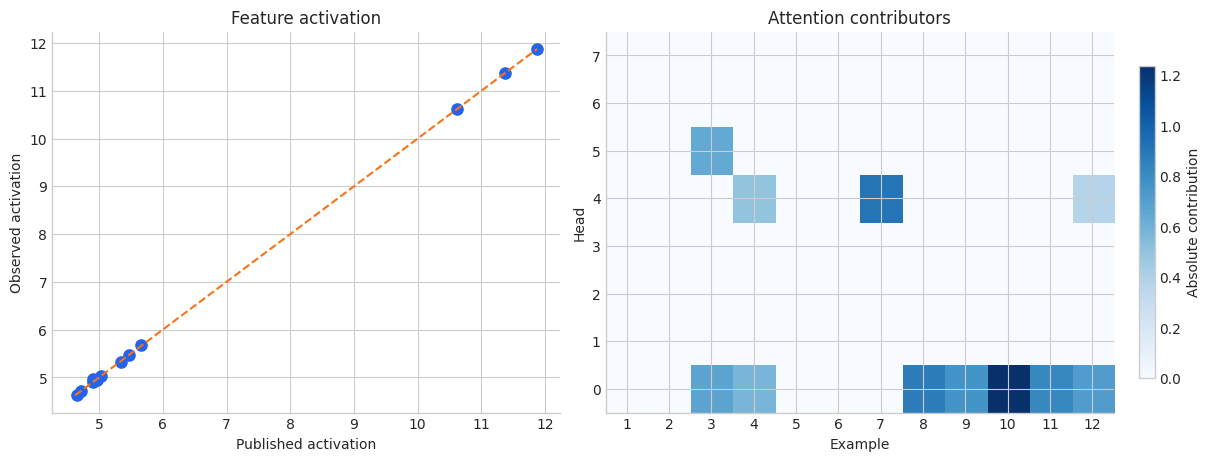

Text,Contributors
But we saw,—
We saw,—
"Since $q(X)=\dim (X)$, we saw","H0 ← ' we', H5 ← ' we'"
"This provides an explicit example for the more general result of [@Litim:2001fd], which states that the optimisation entails a minimum sensitivity condition, while the converse, in general, is not true","H0 ← ' not', H4 ← ' not'"
It may be true,—
One can then pass,—
Actually this is very hard,H4 ← ' very'
For the application purpose it is always desired,H0 ← ' always'
"In fact, the converse is also true",H0 ← ' also'
At first sight one might suspect,H0 ← ' might'


In [4]:
pattern_name = "blocks.0.attn.hook_pattern"
value_name = "blocks.0.attn.hook_v"
feature_input_name = f"blocks.0.{model.feature_input_hook}"
names = {pattern_name, value_name, feature_input_name}
encoder = feature_encoders[feature_layer][:, feature_index].detach().float().cpu()
output_weight = model.blocks[0].attn.W_O.detach().float().cpu()

circuit_artifacts = []
observed_activations = []
published_activations = []
contributor_grid = np.zeros((8, len(reference["samples"])))
example_rows = []

for sample_index, sample in enumerate(reference["samples"]):
    tokens = torch.tensor(sample["input_ids"], device=device).unsqueeze(0)
    with torch.no_grad():
        _, cache = model.run_with_cache(tokens, names_filter=lambda name: name in names, stop_at_layer=1)

    pattern = cache[pattern_name][0].detach().float().cpu()
    values = cache[value_name][0].detach().float().cpu()
    if values.shape[1] != pattern.shape[0]:
        values = values.repeat_interleave(pattern.shape[0] // values.shape[1], dim=1)

    position = sample["target_position"]
    output_gradient = torch.zeros(pattern.shape[1], model.cfg.d_model)
    output_gradient[position] = encoder
    all_attention = attention_contributions(
        pattern,
        values,
        output_weight,
        output_gradient,
        layer=0,
        target_position=position,
    )
    selected_positions = select_projection_outliers(
        torch.tensor([item.score for item in all_attention]), threshold=5.0, largest=True
    )
    selected = tuple(all_attention[item.index] for item in selected_positions)
    feature_input = cache[feature_input_name][0, position].detach()
    activation = float(selected_transcoder.encode(feature_input)[feature_index].float().cpu())

    for item in selected:
        contributor_grid[item.head_index, sample_index] += abs(item.score)
    observed_activations.append(activation)
    published_activations.append(sample["target_activation"])
    example_rows.append(
        {
            "Text": model.tokenizer.decode(sample["input_ids"]),
            "Contributors": ", ".join(
                f"H{item.head_index} ← {model.tokenizer.decode([sample['input_ids'][item.source_token]])!r}"
                for item in selected
            )
            or "—",
        }
    )
    circuit_artifacts.append(
        CircuitLensArtifact(
            target_layer=feature_layer,
            target_feature_index=feature_index,
            target_position=(position,),
            target_activation=activation,
            upstream_features=(),
            attention=selected,
            output_logits=(),
        )
    )


def publish_circuit_batch(raw_artifacts, observed, published):
    return NonTensorData(tuple(raw_artifacts)), observed.float(), published.float()


def cluster_circuits(artifacts):
    return NonTensorData(
        cluster_circuit_artifacts(
            artifacts,
            min_frequency=0.05,
            min_abs_score=0.0,
            eps=0.8,
            min_samples=2,
        )
    )


circuit_workflow = Workflow(
    TensorDictModule(
        publish_circuit_batch,
        in_keys=[("raw", "circuits"), ("raw", "observed"), ("raw", "published")],
        out_keys=[("artifacts", "circuits"), ("activations", "observed"), ("activations", "published")],
    ),
    TensorDictModule(
        lambda observed, published: (observed - published).abs(),
        in_keys=[("activations", "observed"), ("activations", "published")],
        out_keys=[("metrics", "activation_error")],
    ),
    TensorDictModule(
        cluster_circuits,
        in_keys=[("artifacts", "circuits")],
        out_keys=[("artifacts", "clusters")],
    ),
)
circuit_result = circuit_workflow(
    model,
    TensorDict(
        {
            ("raw", "circuits"): NonTensorData(tuple(circuit_artifacts)),
            ("raw", "observed"): torch.tensor(observed_activations),
            ("raw", "published"): torch.tensor(published_activations),
        },
        batch_size=[],
    ),
)
clusters = circuit_result[("artifacts", "clusters")]

with plt.style.context("seaborn-v0_8-whitegrid"):
    figure, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
    axes[0].scatter(published_activations, observed_activations, s=65, color="#2563eb")
    limits = [min(published_activations + observed_activations), max(published_activations + observed_activations)]
    axes[0].plot(limits, limits, linestyle="--", color="#f97316")
    axes[0].set(
        title="Feature activation",
        xlabel="Published activation",
        ylabel="Observed activation",
    )
    image = axes[1].imshow(contributor_grid, aspect="auto", cmap="Blues", origin="lower")
    axes[1].set(title="Attention contributors", xlabel="Example", ylabel="Head")
    axes[1].set_xticks(range(12), range(1, 13))
    axes[1].set_yticks(range(8))
    figure.colorbar(image, ax=axes[1], label="Absolute contribution", shrink=0.82)
    for axis in axes:
        axis.spines[["top", "right"]].set_visible(False)
    plt.show()

display(pd.DataFrame(example_rows).style.hide(axis="index"))

## Cluster the recurring circuits

Finally, a three-step `Workflow` publishes the circuit batch, measures activation agreement, and clusters the relative-token signatures. Even in this small sample, the examples with non-empty attention circuits form a clear recurring group.

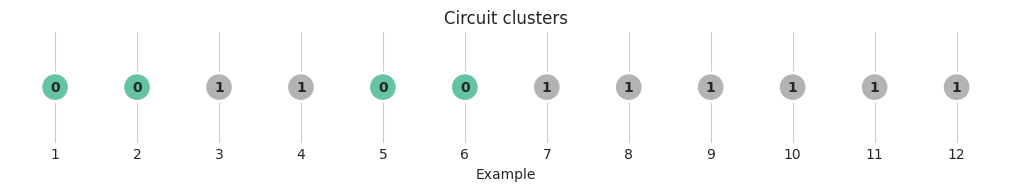

TDHook selected the same contributors as the published sample in **12 of 12 examples**.

In [5]:
with plt.style.context("seaborn-v0_8-whitegrid"):
    figure, axis = plt.subplots(figsize=(10, 1.8), constrained_layout=True)
    axis.scatter(
        range(1, len(clusters.labels) + 1),
        np.zeros(len(clusters.labels)),
        c=clusters.labels,
        cmap="Set2",
        s=420,
        edgecolor="white",
        linewidth=2,
    )
    for index, label in enumerate(clusters.labels, start=1):
        axis.text(index, 0, str(label), ha="center", va="center", fontweight="bold")
    axis.set(title="Circuit clusters", xlabel="Example")
    axis.set_xticks(range(1, len(clusters.labels) + 1))
    axis.set_yticks([])
    axis.spines[:].set_visible(False)
    plt.show()

display(
    Markdown(
        f"TDHook selected the same contributors as the published sample in "
        f"**{sum(set((item.head_index, item.source_token) for item in artifact.attention) == set((entry['head'], entry['source_token']) for entry in sample['attention']) for artifact, sample in zip(circuit_artifacts, reference['samples']))} of 12 examples**."
    )
)

## Takeaway

WeightLens associates this feature with input tokens such as `accused` and `saw`. CircuitLens then shows how a small set of layer-0 attention heads route contextual evidence into the feature. The two views agree with the published feature sample while exposing different parts of the mechanism.